# Handwritten Digit Classification

In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

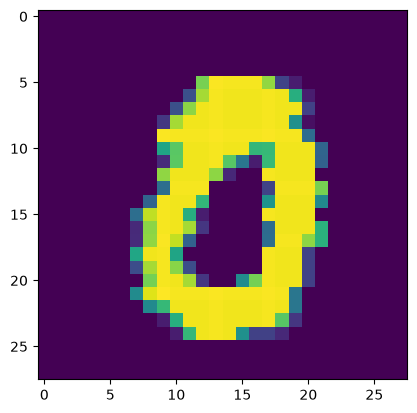

In [3]:
import matplotlib.pyplot as plt
plt.imshow(X_train[69])

In [4]:
X_train = X_train/255
X_test = X_test/255

In [5]:
model = Sequential()

model.add(Flatten(input_shape = (28,28)))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))


d:\DeepLearning.py\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss = 'sparse_categorical_crossentropy',optimizer= 'Adam', metrics = ['accuracy'])


In [8]:
history = model.fit(X_train, y_train, epochs = 10, validation_split = 0.2, verbose = 1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9184 - loss: 0.2882 - val_accuracy: 0.9532 - val_loss: 0.1613
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9629 - loss: 0.1273 - val_accuracy: 0.9620 - val_loss: 0.1206
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9741 - loss: 0.0868 - val_accuracy: 0.9697 - val_loss: 0.0980
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9803 - loss: 0.0641 - val_accuracy: 0.9729 - val_loss: 0.0937
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9859 - loss: 0.0487 - val_accuracy: 0.9741 - val_loss: 0.0866
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9888 - loss: 0.0384 - val_accuracy: 0.9730 - val_loss: 0.0974
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9908 - loss: 0.0304 - val_accuracy: 0.9756 - val_loss: 0.0876
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9923 - loss: 

In [9]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [10]:
import numpy as np
y_pred = np.argmax(y_prob, axis = 1)

In [11]:
from sklearn.metrics import accuracy_score
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

Accuracy Score:  0.9767


In [12]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 970    1    1    0    1    1    3    1    2    0]
 [   0 1122    4    1    0    0    4    2    2    0]
 [   5    0 1011    0    2    0    3    6    5    0]
 [   0    0    4  984    1    8    0    4    4    5]
 [   1    1    3    0  961    0    5    0    2    9]
 [   2    0    0    6    0  873    7    2    1    1]
 [   3    2    0    1    4    4  944    0    0    0]
 [   1    5    7    2    0    0    0 1002    5    6]
 [   2    1    5    9    4    1    2    5  942    3]
 [   2    4    1    9   12    1    1   15    6  958]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.97      0.99      0.98       958
           7       0.97      0.97   

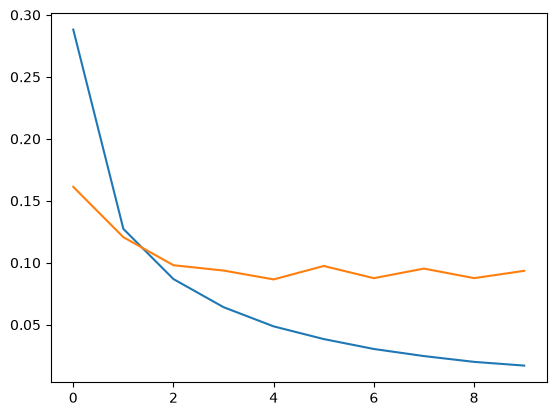

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

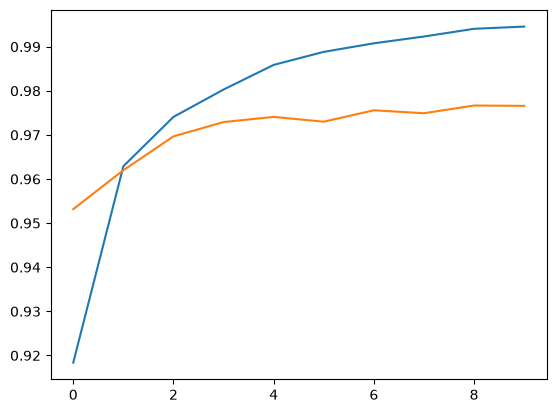

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])